In [1]:
import warnings 
warnings.filterwarnings('ignore')

## K-Nearest-Neighbors

KNN falls in the supervised learning family of algorithms. Informally, this means that we are given a labelled dataset consiting of training observations (x,y) and would like to capture the relationship between x and y. More formally, our goal is to learn a function h:X→Y so that given an unseen observation x, h(x) can confidently predict the corresponding output y.

In this module we will explore the inner workings of KNN, choosing the optimal K values and using KNN from scikit-learn.

## Overview

1.Read the problem statement.

2.Get the dataset.

3.Explore the dataset.

4.Pre-processing of dataset.

5.Visualization

6.Transform the dataset for building machine learning model.

7.Split data into train, test set.

7.Build Model.

8.Apply the model.

9.Evaluate the model.

10.Finding Optimal K value

11.Repeat 7,8,9 steps.

## Problem statement

### Dataset

The data set we’ll be using is the Iris Flower Dataset which was first introduced in 1936 by the famous statistician Ronald Fisher and consists of 50 observations from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals.

**Attributes of the dataset:** https://archive.ics.uci.edu/ml/datasets/Iris

**Train the KNN algorithm to be able to distinguish the species from one another given the measurements of the 4 features.**

## Question 1

Import the data set and print 10 random rows from the data set

In [2]:
# importing necessary libraries 
from sklearn import datasets 
from random import sample
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve
from sklearn import metrics
from sklearn.metrics import roc_curve, auc
from sklearn import model_selection
from sklearn.ensemble import BaggingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
import multiprocessing 
from sklearn.model_selection import GridSearchCV

C:\Users\Jatin_Thakkar\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\ensemble\weight_boosting.py:29: DeprecationWarning: numpy.core.umath_tests is an internal NumPy module and should not be imported. It will be removed in a future NumPy release.
  from numpy.core.umath_tests import inner1d


In [3]:
# loading the iris dataset 
iris = datasets.load_iris()


# X -> features, y -> label 
X = iris.data 
y = iris.target
features = pd.DataFrame({'sepal length (cm)':X[:,0],'sepal width (cm)':X[:,1],
                        'petal length (cm)':X[:,2], 'petal width (cm)':X[:,3]})
target = pd.DataFrame({'target_values':y})
dataset = features.join(target, how='outer')
dataset["target_names"]=dataset["target_values"].apply(lambda x: 'Iris Setosa' if x == 0 
                                                       else 'Iris Versicolour' if x == 1 
                                                       else 'Iris Virginica')

# Correcting data as suggested on 'https://archive.ics.uci.edu/ml/datasets/iris'
#The 35th sample should be: 4.9,3.1,1.5,0.2,"Iris-setosa" where the error is in the 
#fourth feature. The 38th sample: 4.9,3.6,1.4,0.1,"Iris-setosa" where the errors are 
#in the second and third features
dataset.at[34, 'petal width (cm)'] = 0.2
dataset.at[37, 'sepal width (cm)'] = 3.6
dataset.at[37, 'petal length (cm)'] = 1.4

In [4]:
# randomly sample 10 elements from your dataframe
sample = dataset.sample(n=10)
sample

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target_values,target_names
97,6.2,2.9,4.3,1.3,1,Iris Versicolour
44,5.1,3.8,1.9,0.4,0,Iris Setosa
99,5.7,2.8,4.1,1.3,1,Iris Versicolour
136,6.3,3.4,5.6,2.4,2,Iris Virginica
25,5.0,3.0,1.6,0.2,0,Iris Setosa
2,4.7,3.2,1.3,0.2,0,Iris Setosa
105,7.6,3.0,6.6,2.1,2,Iris Virginica
92,5.8,2.6,4.0,1.2,1,Iris Versicolour
77,6.7,3.0,5.0,1.7,1,Iris Versicolour
140,6.7,3.1,5.6,2.4,2,Iris Virginica


## Data Pre-processing

## Question 2 - Estimating missing values

*Its not good to remove the records having missing values all the time. We may end up loosing some data points. So, we will have to see how to replace those missing values with some estimated values (median) *

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 150 entries, 0 to 149
Data columns (total 6 columns):
sepal length (cm)    150 non-null float64
sepal width (cm)     150 non-null float64
petal length (cm)    150 non-null float64
petal width (cm)     150 non-null float64
target_values        150 non-null int32
target_names         150 non-null object
dtypes: float64(4), int32(1), object(1)
memory usage: 12.6+ KB


### NOTE: No values found missing

## Question 3 - Dealing with categorical data

Change all the classes to numericals (0to2).

### NOTE: 'target_values' column provides for numerical value of classes

## Question 4

*Observe the association of each independent variable with target variable and drop variables from feature set having correlation in range -0.1 to 0.1 with target variable.*

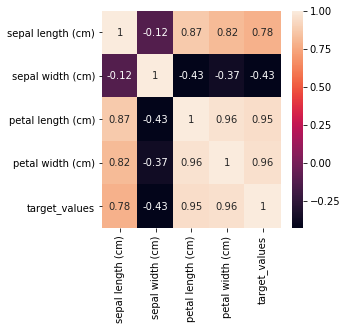

In [6]:
corr = dataset.corr()
plt.figure(figsize=(4,4)) 
sns.heatmap(corr, annot=True)

### NOTE: For categorical variable target_values, measuring correlation with other numerical variables is likely to provide inappropriate reading.

## Question 5

*Observe the independent variables variance and drop such variables having no variance or almost zero variance(variance < 0.1). They will be having almost no influence on the classification.*

In [7]:
print("Variance for sepal length (cm)", dataset['sepal length (cm)'].var())
print("Variance for sepal width (cm)", dataset['sepal width (cm)'].var())
print("Variance for petal length (cm)", dataset['petal length (cm)'].var())
print("Variance for petal width (cm)", dataset['petal width (cm)'].var())

Variance for sepal length (cm) 0.6856935123042505
Variance for sepal width (cm) 0.1899794183445188
Variance for petal length (cm) 3.1162778523489942
Variance for petal width (cm) 0.5810062639821029


### NOTE: No features recorded a variance below 0.1, all retained for further study

## Question 6

*Plot the scatter matrix for all the variables.*

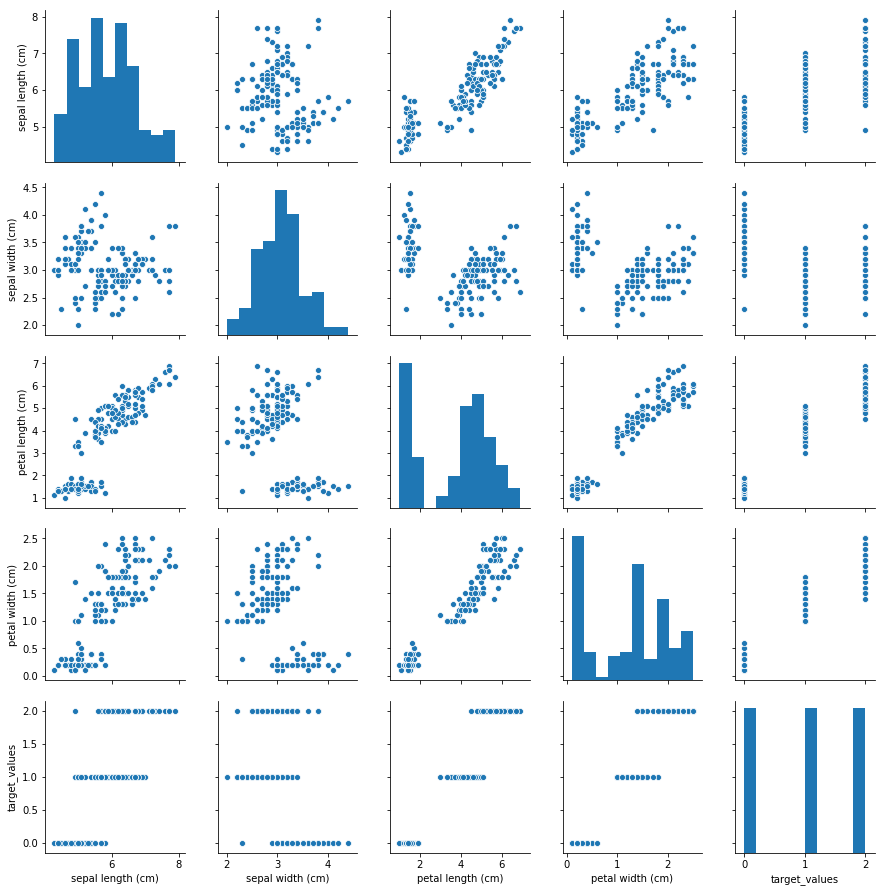

In [8]:
sns.pairplot(dataset)

## Split the dataset into training and test sets

## Question 7

*Split the dataset into training and test sets with 80-20 ratio.*

In [9]:
X = dataset.drop("target_names", axis=1)
X = X.drop("target_values", axis=1)
y = dataset["target_values"]

In [10]:
test_size = 0.20 # taking 80:20 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

## Question 8 - Model

*Build the model and train and test on training and test sets respectively using **scikit-learn**. Print the Accuracy of the model with different values of **k=3,5,9**.*

**Hint:** For accuracy you can check **accuracy_score()** in scikit-learn

In [11]:
KNN_3 = KNeighborsClassifier(n_neighbors= 3)
KNN_3.fit(X_train, y_train)
ypred_k3 = KNN_3.predict(X_test)

In [12]:
accuracy_score(y_test, ypred_k3)

0.9

In [13]:
KNN_5 = KNeighborsClassifier(n_neighbors= 5)
KNN_5.fit(X_train, y_train)
ypred_k5 = KNN_5.predict(X_test)

In [14]:
accuracy_score(y_test, ypred_k5)

0.9

In [15]:
KNN_9 = KNeighborsClassifier(n_neighbors= 9)
KNN_9.fit(X_train, y_train)
ypred_k9 = KNN_9.predict(X_test)

In [16]:
accuracy_score(y_test, ypred_k9)

0.9

In [17]:
# k-fold evaluate each model in turn
def results_plot(metric, models, X, y, seed=7):
    results = []
    names = []
    scoring = metric # change evaluation metric as requred, example - accuracy, precision, f1, recall
    for name, model in models:
        kfold = model_selection.KFold(n_splits=5,random_state=seed)
        cv_results = model_selection.cross_val_score(model, X, y, cv=kfold, scoring=scoring)
        results.append(cv_results)
        names.append(name)
        msg = "%s: %f (%f)" % (name, np.mean(cv_results), cv_results.var())
        print(msg)
    # boxplot algorithm comparison
    fig = plt.figure()
    fig.suptitle('Algorithm Comparison')
    ax = fig.add_subplot(111)
    plt.boxplot(results)
    ax.set_xticklabels(names)
    plt.show()

In [18]:
models = []
models.append(('KNN_3', KNN_3))
models.append(('KNN_5', KNN_5))
models.append(('KNN_9', KNN_9))

KNN_3: 0.906667 (0.008622)
KNN_5: 0.913333 (0.006933)
KNN_9: 0.920000 (0.008267)


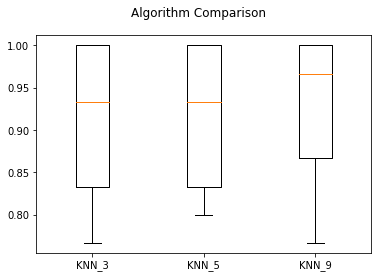

In [19]:
results_plot('accuracy', models, X, y, seed=7)

## Question 9 - Cross Validation

Run the KNN with no of neighbours to be 1,3,5..19 and *Find the **optimal number of neighbours** from the above list using the Mis classification error

Hint:

Misclassification error (MSE) = 1 - Test accuracy score. Calculated MSE for each model with neighbours = 1,3,5...19 and find the model with lowest MSE

In [20]:
KNN_1 = KNeighborsClassifier(n_neighbors= 1)
KNN_1.fit(X_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=1, p=2,
           weights='uniform')

In [21]:
KNN_7 = KNeighborsClassifier(n_neighbors= 7)
KNN_7.fit(X_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=7, p=2,
           weights='uniform')

In [22]:
KNN_11 = KNeighborsClassifier(n_neighbors= 11)
KNN_11.fit(X_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=11, p=2,
           weights='uniform')

In [23]:
KNN_13 = KNeighborsClassifier(n_neighbors= 13)
KNN_13.fit(X_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=13, p=2,
           weights='uniform')

In [24]:
KNN_15 = KNeighborsClassifier(n_neighbors= 15)
KNN_15.fit(X_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=15, p=2,
           weights='uniform')

In [25]:
KNN_17 = KNeighborsClassifier(n_neighbors= 17)
KNN_17.fit(X_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=17, p=2,
           weights='uniform')

In [26]:
KNN_19 = KNeighborsClassifier(n_neighbors= 11)
KNN_19.fit(X_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=11, p=2,
           weights='uniform')

In [27]:
MSE_scores = {"k-value":['1', "3", "5", "7", "9", "11", "13", "15", "17", "19"]}
k_iter = pd.DataFrame(MSE_scores, columns = ['k-value'])

In [28]:
models = []
models.append(('KNN_1', KNN_1))
models.append(('KNN_3', KNN_3))
models.append(('KNN_5', KNN_5))
models.append(('KNN_7', KNN_7))
models.append(('KNN_9', KNN_9))
models.append(('KNN_11', KNN_11))
models.append(('KNN_13', KNN_13))
models.append(('KNN_15', KNN_15))
models.append(('KNN_17', KNN_17))
models.append(('KNN_19', KNN_19))

KNN_1: 0.926667 (0.004622)
KNN_3: 0.906667 (0.008622)
KNN_5: 0.913333 (0.006933)
KNN_7: 0.920000 (0.007378)
KNN_9: 0.920000 (0.008267)
KNN_11: 0.913333 (0.007378)
KNN_13: 0.906667 (0.006844)
KNN_15: 0.900000 (0.008889)
KNN_17: 0.880000 (0.016267)
KNN_19: 0.913333 (0.007378)


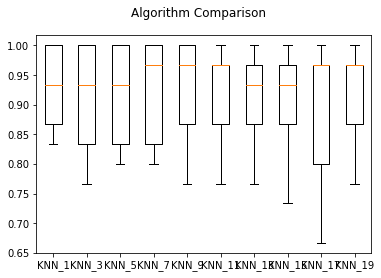

In [29]:
results_plot('accuracy', models, X, y, seed=7)

In [30]:
k_iter.insert(1, "Kfold_MSE", [1-0.926667, 1-0.906667, 1-0.913333, 1-0.920000, 1-0.920000, 
                              1-0.913333, 1-0.906667, 1-0.900000, 1-0.880000, 1-0.913333], True)
k_iter.insert(2, "Kfold_acc_var", [0.004622, 0.008622, 0.006933, 0.007378, 0.008267, 
                                   0.007378, 0.006844, 0.008889, 0.016267, 0.007378], True)
k_iter

,k-value,Kfold_MSE,Kfold_acc_var
0,1,0.073333,0.004622
1,3,0.093333,0.008622
2,5,0.086667,0.006933
3,7,0.080000,0.007378
4,9,0.080000,0.008267
5,11,0.086667,0.007378
6,13,0.093333,0.006844
7,15,0.100000,0.008889
8,17,0.120000,0.016267
9,19,0.086667,0.007378


### Based on MSE values generated from K-fold validation, K=7 and K=9 provide for the lowest misclassification error. K=7 provides for the minimum variance in accuracy_score and hence should be the optimum value

## Question 10

*Plot misclassification error vs k (with k value on X-axis) using matplotlib.*

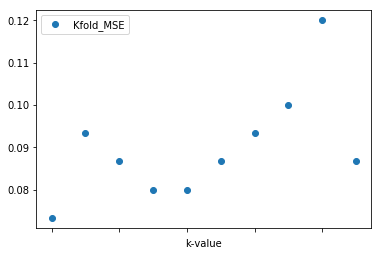

In [31]:
k_iter.plot(x='k-value', y='Kfold_MSE', style='o')

# Naive Bayes with Iris Data

### Slice  Iris data set for Independent variables and dependent variables
#### Please note 'Species' is my dependent variables, name it y and independent set data as X

In [32]:
X = iris.data 
y = iris.target

In [33]:
#Check the dataset
print(y)
print(X)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 

# Question 11 
Find the distribution of target variable (Class)

And, Plot the distribution of target variable using histogram

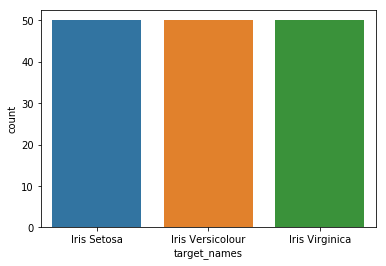

In [34]:
sns.countplot(x="target_names",data=dataset)

### Question 12 
Find Correlation among all variables and give your insights 

In [35]:
#Please note, it's Require to remove correlated features because they are voted twice in the model and 
## it can lead to over inflating importance.We will ignore it here

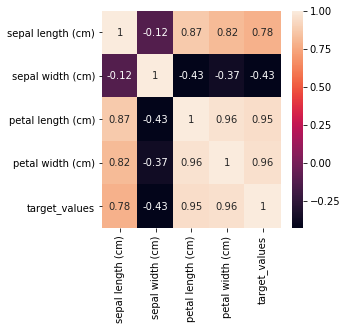

In [36]:
corr = dataset.corr()
plt.figure(figsize=(4,4)) 
sns.heatmap(corr, annot=True)

### Observations - Sepal width is the only variable to record low correlation with other variables, rest are highly correlated with each other (target_value correlations ignored since the same is categorical column)

### Split data in Training and test set in 80:20.

In [37]:
X = dataset.drop("target_names", axis=1)
X = X.drop("target_values", axis=1)
y = dataset["target_values"]

In [38]:
test_size = 0.20 # taking 80:20 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

### Question 13 
Do Feature Scaling 

In [39]:
# Use StandardScaler or similar methods
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [40]:
# Redoing train-test split post scaling
test_size = 0.20 # taking 80:20 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

### Question 14 
Train and Fit NaiveBayes Model

In [41]:
#Fit the model
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB(priors=None)

In [42]:
#Predict
ypred_gb = model.predict(X_test)

### Question 15 
Print Accuracy and Confusion Matrix and Conclude your findings

In [43]:
# show Confusion Matrix
metrics.confusion_matrix(ypred_gb, y_test)

array([[7, 0, 0],
       [0, 9, 2],
       [0, 3, 9]], dtype=int64)

In [44]:
# show accuracy
model_score = model.score(X_test, y_test)
model_score

0.8333333333333334

In [45]:
#Show precision and Recall metrics
pd.DataFrame(data=[recall_score(y_test, ypred_gb, average=None),
                   precision_score(y_test, ypred_gb, average=None)], 
             index=["recall", "precision"])

,0,1,2
recall,1.0,0.750000,0.818182
precision,1.0,0.818182,0.750000


# For Practice  - Optional

All the questions from 16 to 20 are for practice.

# Using SVM with Diebetes Dataset

In [46]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Question 16 
Read the input file 'Diabetes.csv' using Pandas and check it's column names.

Check dimension of dataset.

Check distribution of dependent variable, Outcome and plot it.


In [65]:
# Since it is a data file with no header, we will supply the column names which have been obtained from the above URL 
# Create a python list of column names called "names"
colnames = ['preg', 'gluc', 'BP', 'skin', 'insu', 'BMI', 'pedi', 'age', 'class']
pima_df = pd.read_csv("pima-indians-diabetes-1.data", names= colnames)

In [48]:
# Eye ball the imported dataset

In [66]:
pima_df.head()

,preg,gluc,BP,skin,insu,BMI,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Out of  768 data points, 500 are labeled as 0 and 268 as 1.
### Outcome 0 means No diabetes, outcome 1 means diabetes

In [67]:
pima_df['class'].value_counts()

0    500
1    268
Name: class, dtype: int64

In [68]:
# Check data types and info of dataset

In [69]:
pima_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
preg     768 non-null int64
gluc     768 non-null int64
BP       768 non-null int64
skin     768 non-null int64
insu     768 non-null int64
BMI      768 non-null float64
pedi     768 non-null float64
age      768 non-null int64
class    768 non-null int64
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [70]:
zeros = 768 - pima_df.astype(bool).sum(axis=0)
zeros

preg     111
gluc       5
BP        35
skin     227
insu     374
BMI       11
pedi       0
age        0
class    500
dtype: int64

In [71]:
# Replacing all the 0s in the column with the median of the same column value
median_preg = pima_df['preg'].median()
pima_df['preg']=pima_df.preg.mask(pima_df.preg == 0,median_preg)
median_gluc = pima_df['gluc'].median()
pima_df['gluc']=pima_df.gluc.mask(pima_df.gluc == 0,median_gluc)
median_BP = pima_df['BP'].median()
pima_df['BP']=pima_df.BP.mask(pima_df.BP == 0,median_BP)
median_skin = pima_df['skin'].median()
pima_df['skin']=pima_df.skin.mask(pima_df.skin == 0,median_skin)
median_insu = pima_df['insu'].median()
pima_df['insu']=pima_df.insu.mask(pima_df.insu == 0,median_insu)
median_BMI = pima_df['BMI'].median()
pima_df['BMI']=pima_df.BMI.mask(pima_df.BMI == 0,median_BMI)
median_pedi = pima_df['pedi'].median()
pima_df['pedi']=pima_df.pedi.mask(pima_df.pedi == 0,median_pedi)
median_age = pima_df['age'].median()
pima_df['age']=pima_df.age.mask(pima_df.age == 0,median_age)

In [72]:
pima_df_copy = pima_df
pima_df_copy.describe()

,preg,gluc,BP,skin,insu,BMI,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,4.278646,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.021516,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,1.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,2.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [73]:
# Checking variance for each feature
# Observe the independent variables variance and drop such variables having no variance or almost zero 
#variance(variance < 0.1). They will be having almost no influence on the classification.
print("Variance for preg", pima_df['preg'].var())
print("Variance for gluc", pima_df['gluc'].var())
print("Variance for BP", pima_df['BP'].var())
print("Variance for skin", pima_df['skin'].var())
print("Variance for insu", pima_df['insu'].var())
print("Variance for BMI", pima_df['BMI'].var())
print("Variance for pedi", pima_df['pedi'].var())
print("Variance for age", pima_df['age'].var())

Variance for preg 9.12955644285089
Variance for gluc 926.4892438070405
Variance for BP 146.32874124022163
Variance for skin 85.1747049516518
Variance for insu 11140.295535568774
Variance for BMI 47.270664096452656
Variance for pedi 0.10977863787313938
Variance for age 138.30304589037365


# Question 17 
Check data distribution using summary statistics and provide your findings.

Do correlation analysis and bivariate viualization with Insights


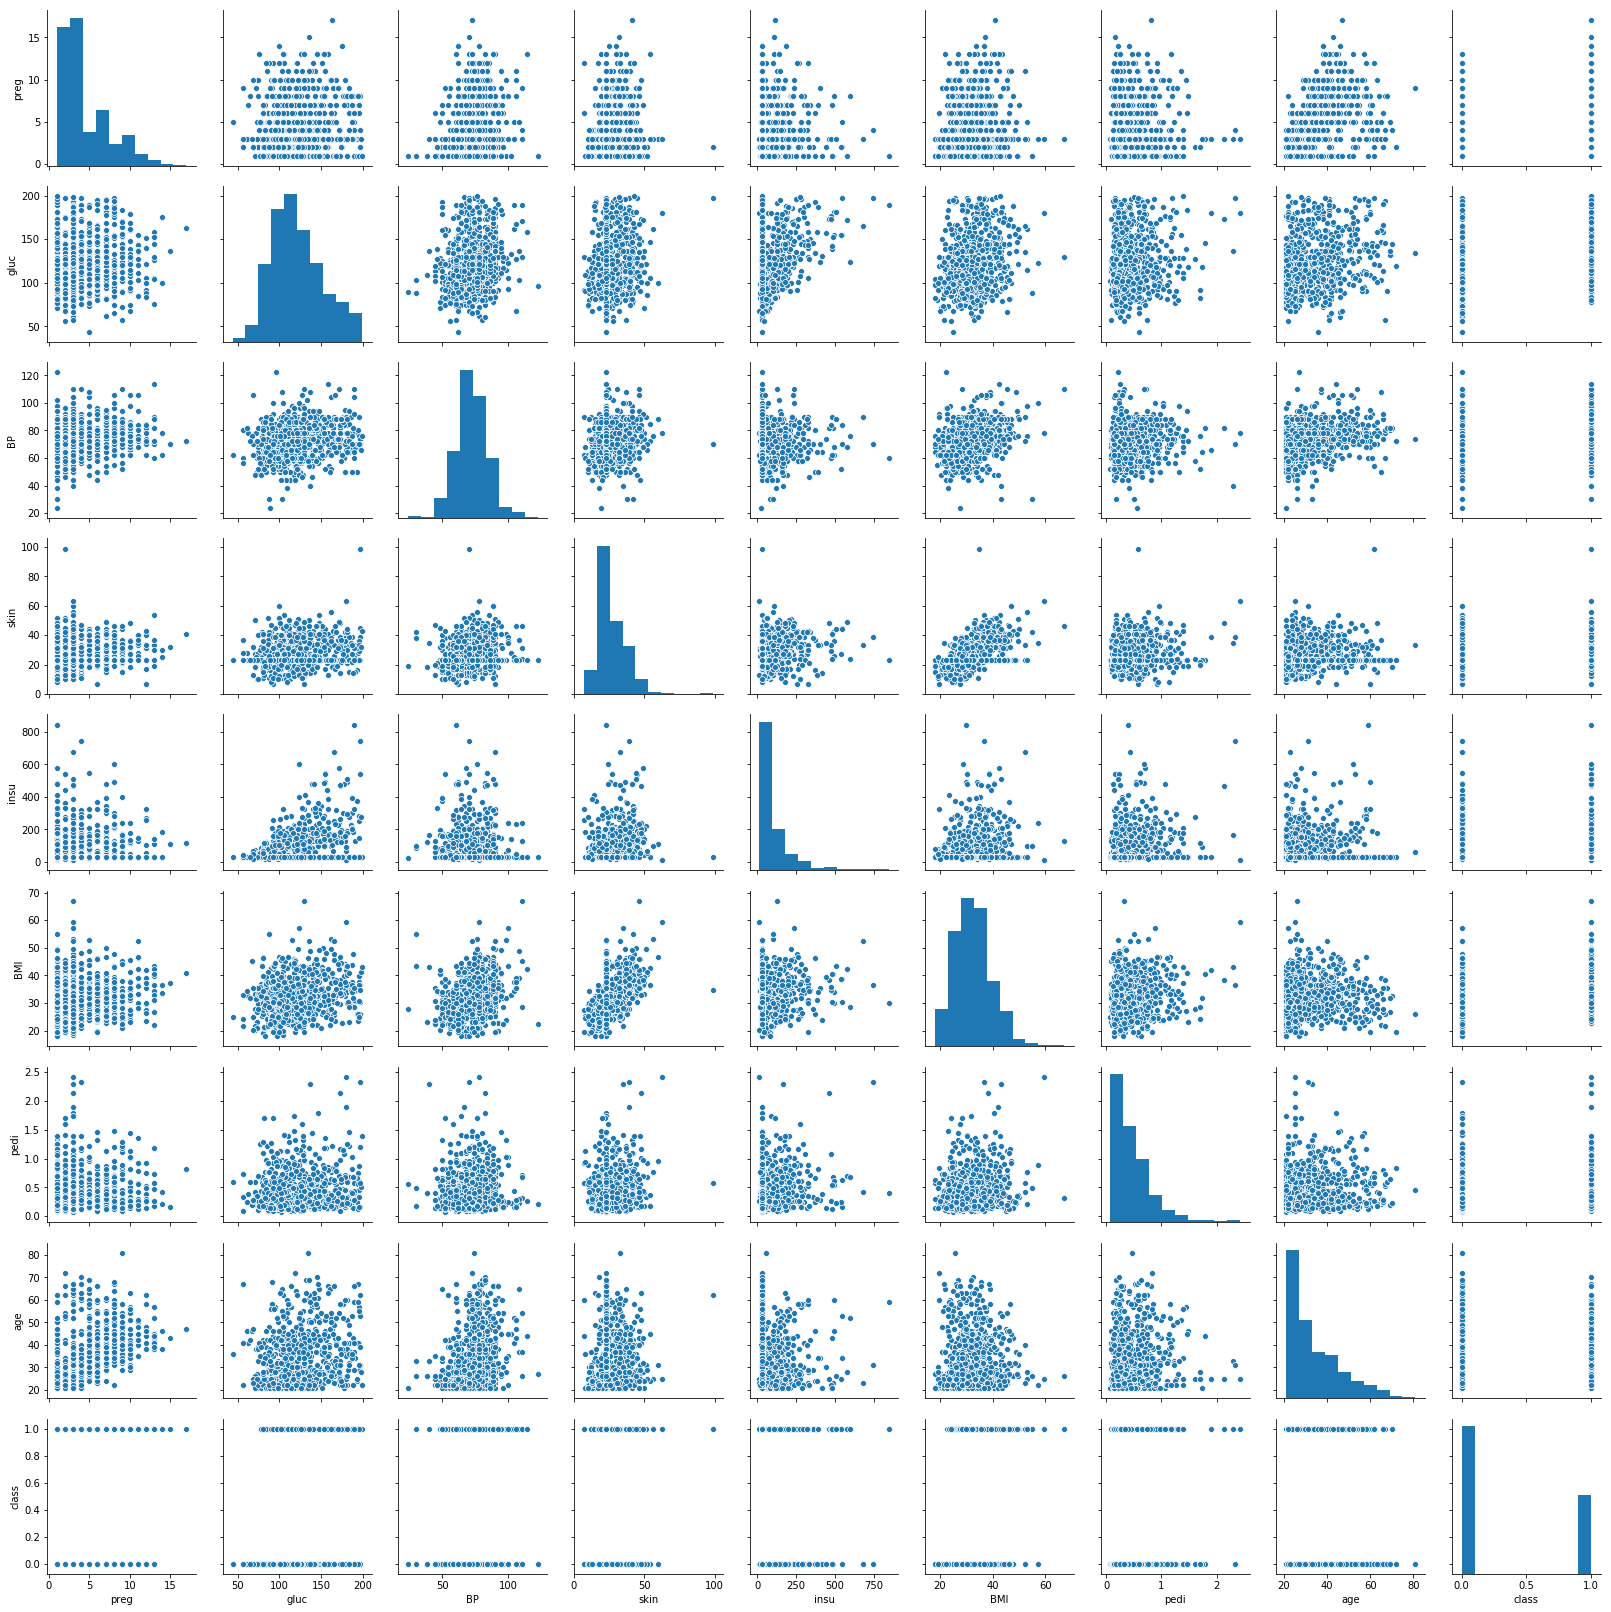

In [57]:
sns.pairplot(pima_df)

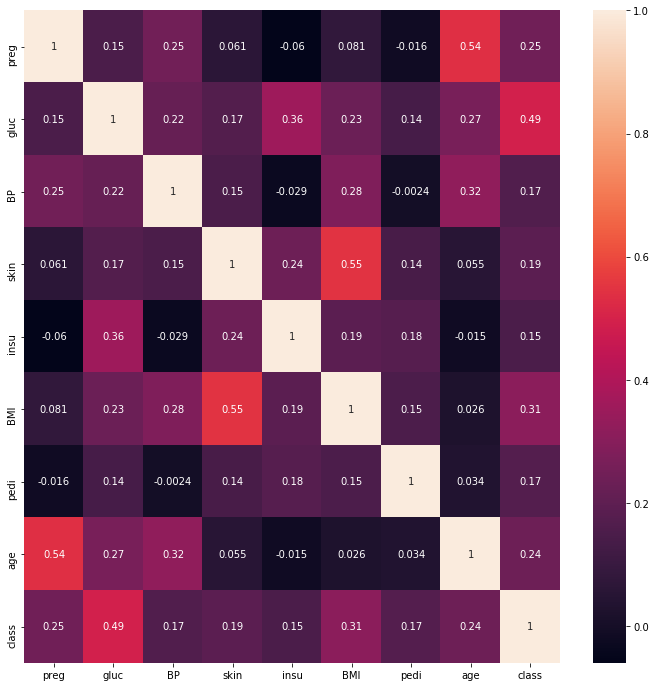

In [58]:
corr = pima_df.corr()
plt.figure(figsize=(12,12)) 
sns.heatmap(corr, annot=True)

### Key observations: No significant linear relationship noted between target and independent variable except one - Plasma glucose concentration a 2 hours in an oral glucose tolerance test with onset of diabetes

# Question 18 
Do train and test split. 
Optionally - You can do with stratify sampling(optional) on Outcome variable to maintain the distribution of dependent variable

In [59]:
X = pima_df.drop("class", axis=1)
y = pima_df["class"]

In [60]:
# Train-test split with stratify sampling
y = pima_df.pop('class')
test_size = 0.20 # taking 80:20 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed, stratify=y)

# Question 19 
Train Support Vector Machine Model(1 Marks)

In [61]:
# use from sklearn.svm import SVC
SVC_model = SVC()

In [62]:
# your insights
SVC_model.fit(X_train, y_train)
SVC_ypred = SVC_model.predict(X_test)
metrics.confusion_matrix(SVC_ypred, y_test)

array([[100,  54],
       [  0,   0]], dtype=int64)

# Question 20
Scale the data points using MinMaxScaler

Fit SVM Model on Scale data and give your observation

In [74]:
# Use StandardScaler or similar methods
#scaler = StandardScaler()
#X = scaler.fit_transform(X)
# Scale data to 0-1
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [75]:
# Train-test split with stratify sampling
y = pima_df.pop('class')
test_size = 0.20 # taking 80:20 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed, stratify=y)

In [76]:
# your insights
SVC_model = SVC(probability=True, random_state=7)
SVC_model.fit(X_train, y_train)
SVC_ypred = SVC_model.predict(X_test)
metrics.confusion_matrix(SVC_ypred, y_test)

array([[91, 25],
       [ 9, 29]], dtype=int64)

In [77]:
model_score =SVC_model.score(X_test, y_test)
model_score

0.7792207792207793

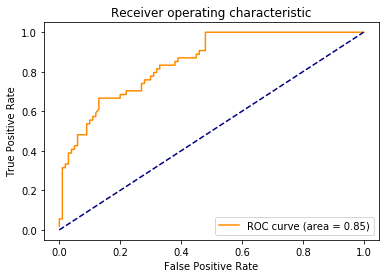

In [78]:
SVC_ypred_prob = SVC_model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, SVC_ypred_prob[::,1])
roc_auc = auc(fpr, tpr)
roc_auc
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

#we can try increasing either C or gamma to fit a more complex model.

### NOTE: The above requirement (increasing either C or gamma) to be tested in GridSearch Approach

# Optional Question - 
Try improving the model accuracy using C=1000 (1 Marks)

In [79]:
# your insights
SVC_model = SVC(C=1000, probability=True, random_state=7)
SVC_model.fit(X_train, y_train)
SVC_ypred = SVC_model.predict(X_test)
metrics.confusion_matrix(SVC_ypred, y_test)

array([[86, 23],
       [14, 31]], dtype=int64)

In [80]:
model_score =SVC_model.score(X_test, y_test)
model_score

0.7597402597402597

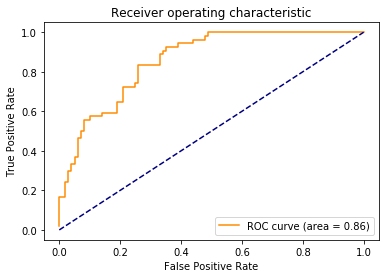

In [81]:
SVC_ypred_prob = SVC_model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, SVC_ypred_prob[::,1])
roc_auc = auc(fpr, tpr)
roc_auc
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

### Here, increasing C allows us to improve the model, resulting in ??? accuracy.
### Let's try to explore different Kernel and C (Bonus for practice)

### NOTE: Using C=1000 reduces the accuracy by 2% but improved the AUC by 1%

In [82]:
param_grid = [{'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'C': [0.1, 0.5, 1.0, 10, 100, 500, 1000], 
              'gamma': ['auto', 'scale'], 'probability':[True]}]

### Here, increasing C allows us to improve the model, resulting in ??? accuracy.
### Let's try to explore different Kernel and C (Bonus for practice)

In [83]:
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=10, n_jobs=-1)

In [84]:
#gs.fit(X_train, y_train) 

In [88]:
#gs.best_estimator_

In [86]:
#gs.best_score_ 